
---

# 🧹 **`Dealing with Data Inconsistencies & Anomalies in Python for Machine Learning`** 📊

In **Data Science** and **Machine Learning (ML)**, **data quality** plays a crucial role in building accurate and reliable models. **Data inconsistencies** and **anomalies** (also known as **outliers**) can lead to **misleading insights**, **biased models**, and **reduced accuracy**.

This guide covers:  
1. ✅ **What Are Data Inconsistencies & Anomalies?**  
2. 📊 **Detecting Data Inconsistencies**  
3. 🧮 **Identifying Anomalies (Outliers)**  
4. 🛠️ **Handling Data Inconsistencies & Anomalies**  
5. 🤖 **Using Python Libraries for Data Cleaning**  

---

## ✅ **1. What Are Data Inconsistencies & Anomalies?**  

### 🔄 **Data Inconsistencies:**  
Irregularities or errors in data formatting, structure, or semantics.

**Examples:**  
- Mismatched data formats (e.g., "12/01/2024" vs. "2024-01-12")  
- Typos in categorical data (e.g., "HR" vs. "Hr" vs. "Human Resources")  
- Duplicate rows or entries  
- Inconsistent units (e.g., "kg" vs. "lbs")  

---

### ⚠️ **Anomalies (Outliers):**  
Data points that deviate significantly from the rest of the dataset.

**Types of Anomalies:**  
1. **Point Anomalies:** Single data points that are outliers (e.g., a salary of $1,000,000 in a dataset of $50,000–$100,000).  
2. **Contextual Anomalies:** Data points that are normal in one context but anomalous in another (e.g., high sales during Black Friday).  
3. **Collective Anomalies:** A group of data points behaving abnormally together (e.g., a sudden drop in website traffic).  

---

## 📊 **2. Detecting Data Inconsistencies**  

### 📁 **Sample Dataset:**



In [1]:

import pandas as pd
import numpy as np

# Sample DataFrame with inconsistencies
data = {
    'ID': [101, 102, 103, 104, 104],
    'Name': ['Alice', 'Bob', 'Charlie', 'David', 'David'],
    'Age': [25, 30, np.nan, 22, 22],
    'Salary': [50000, '60000', 55000, 'Fifty Thousand', 52000],
    'Join_Date': ['2023-01-01', '01/02/2023', '2023/03/15', '2023-04-01', '2023-04-01'],
    'Department': ['HR', 'IT', 'finance', 'IT', 'IT']
}

df = pd.DataFrame(data)
df


,ID,Name,Age,Salary,Join_Date,Department
0,101,Alice,25.0,50000,2023-01-01,HR
1,102,Bob,30.0,60000,01/02/2023,IT
2,103,Charlie,NaN,55000,2023/03/15,finance
3,104,David,22.0,Fifty Thousand,2023-04-01,IT
4,104,David,22.0,52000,2023-04-01,IT



---

### 🔍 **2.1 Detecting Duplicate Rows:**

In [2]:

# Find duplicates
duplicates = df[df.duplicated()]
print("Duplicate Rows:\n", duplicates)

# Remove duplicates
df = df.drop_duplicates()


Duplicate Rows:
 Empty DataFrame
Columns: [ID, Name, Age, Salary, Join_Date, Department]
Index: []



---

### 🧹 **2.2 Standardizing Categorical Data:**


In [3]:

# Convert 'Department' to lowercase for consistency
df['Department'] = df['Department'].str.lower()

# Correct typos or inconsistent names
df['Department'] = df['Department'].replace({'finance': 'finance', 'hr': 'human resources'})

print(df['Department'].unique())


['human resources' 'it' 'finance']




---

### 📅 **2.3 Formatting Dates:**



In [4]:

# Convert 'Join_Date' to datetime format
df['Join_Date'] = pd.to_datetime(df['Join_Date'], errors='coerce')

# Check for invalid dates
print(df['Join_Date'])


0   2023-01-01
1          NaT
2          NaT
3   2023-04-01
4   2023-04-01
Name: Join_Date, dtype: datetime64[ns]




---

### 💰 **2.4 Handling Incorrect Data Types:**

In [5]:

# Convert 'Salary' to numeric, coercing errors
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')

# Identify invalid entries
print(df[df['Salary'].isnull()])

# Replace invalid salary values with median (avoiding inplace on chained assignment)
df['Salary'] = df['Salary'].fillna(df['Salary'].median())


    ID   Name   Age  Salary  Join_Date Department
3  104  David  22.0     NaN 2023-04-01         it



---

## 🧮 **3. Identifying Anomalies (Outliers)**  

### 📊 **3.1 Using Descriptive Statistics:**


In [6]:

# Summary statistics
print(df.describe())


              ID        Age       Salary            Join_Date
count    5.00000   4.000000      5.00000                    3
mean   102.80000  24.750000  54100.00000  2023-03-02 00:00:00
min    101.00000  22.000000  50000.00000  2023-01-01 00:00:00
25%    102.00000  22.000000  52000.00000  2023-02-15 00:00:00
50%    103.00000  23.500000  53500.00000  2023-04-01 00:00:00
75%    104.00000  26.250000  55000.00000  2023-04-01 00:00:00
max    104.00000  30.000000  60000.00000  2023-04-01 00:00:00
std      1.30384   3.774917   3781.53408                  NaN



---

### 📏 **3.2 Z-Score Method:**  
A Z-score > 3 or < -3 is often considered an outlier.


In [7]:

from scipy import stats

# Calculate Z-scores
z_scores = stats.zscore(df[['Age', 'Salary']])
outliers = (abs(z_scores) > 3)

# Identify rows with outliers
print(df[outliers.any(axis=1)])


Empty DataFrame
Columns: [ID, Name, Age, Salary, Join_Date, Department]
Index: []



---

### 📊 **3.3 Interquartile Range (IQR) Method:**  
Identifies outliers outside the 1.5×IQR range.


In [8]:

# IQR Method
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier limits
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Filter out outliers
outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
print("Outliers:\n", outliers)


Outliers:
     ID Name   Age   Salary Join_Date Department
1  102  Bob  30.0  60000.0       NaT         it



---

### 📊 **3.4 Visualization Techniques:**

#### 📉 **Boxplot (for detecting outliers):**


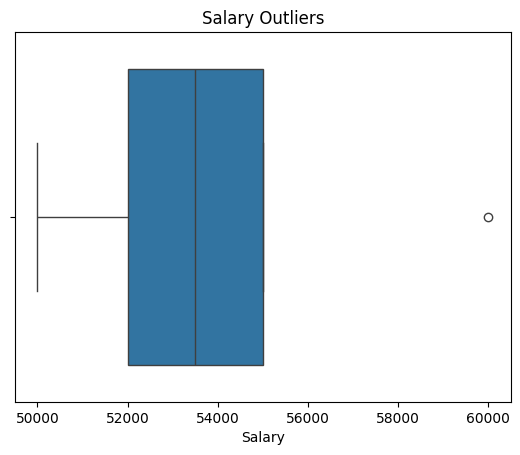

In [9]:

import matplotlib.pyplot as plt
import seaborn as sns

# Boxplot for Salary
sns.boxplot(x=df['Salary'])
plt.title("Salary Outliers")
plt.show()




---

#### 📊 **Scatter Plot (to detect anomalies in multi-dimensional data):**


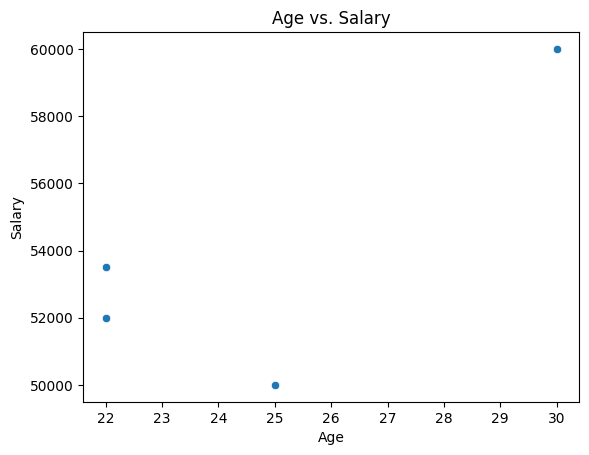

In [10]:

# Scatter plot for Age vs. Salary
sns.scatterplot(data=df, x='Age', y='Salary')
plt.title("Age vs. Salary")
plt.show()



---

## 🛠️ **4. Handling Data Inconsistencies & Anomalies**  

### ⚡ **4.1 Fixing Inconsistent Data:**

| **Problem**               | **Solution**                       |
|---------------------------|-------------------------------------|
| Mismatched Date Formats    | Convert using `pd.to_datetime()`   |
| Typos in Categories        | Use `.replace()` or `.map()`       |
| Incorrect Data Types       | Use `pd.to_numeric()` or `.astype()` |
| Duplicate Rows             | Use `.drop_duplicates()`           |

---

### ⚡ **4.2 Handling Outliers:**

| **Strategy**         | **When to Use**                           |
|----------------------|-------------------------------------------|
| **Remove Outliers**   | If outliers are data entry errors        |
| **Cap/Floor Values**  | When outliers are extreme but valid      |
| **Use Robust Models** | For ML models tolerant to outliers (e.g., Random Forest) |
| **Transform Data**    | Apply log or Box-Cox transformations     |


In [11]:

# Capping Outliers at Upper/Lower Bounds
df['Salary'] = np.where(df['Salary'] > upper_bound, upper_bound, df['Salary'])



---

## 🤖 **5. Anomaly Detection with Machine Learning**  

### 🔍 **5.1 Isolation Forest (Unsupervised Anomaly Detection):**

In [12]:


from sklearn.ensemble import IsolationForest

# Train Isolation Forest
iso_forest = IsolationForest(contamination=0.1)
df['Anomaly'] = iso_forest.fit_predict(df[['Age', 'Salary']])

# -1 indicates anomaly
print(df[df['Anomaly'] == -1])


    ID Name   Age   Salary Join_Date Department  Anomaly
1  102  Bob  30.0  59500.0       NaT         it       -1



---

### 🔍 **5.2 DBSCAN (Density-Based Clustering for Anomalies):**


In [ ]:

from sklearn.cluster import DBSCAN

# Fill missing values in 'Age' with the median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Apply DBSCAN
dbscan = DBSCAN(eps=3, min_samples=2)
df['Cluster'] = dbscan.fit_predict(df[['Age', 'Salary']])

# -1 indicates noise (outliers)
print(df[df['Cluster'] == -1])


    ID     Name   Age   Salary  Join_Date       Department  Anomaly  Cluster
0  101    Alice  25.0  50000.0 2023-01-01  human resources        1       -1
1  102      Bob  30.0  59500.0        NaT               it       -1       -1
2  103  Charlie  23.5  55000.0        NaT          finance        1       -1
3  104    David  22.0  53500.0 2023-04-01               it        1       -1
4  104    David  22.0  52000.0 2023-04-01               it        1       -1



---

## ⚖️ **6. Best Practices for Handling Inconsistencies & Anomalies:**  

✔ **Always visualize data** before and after cleaning.  
✔ **Document changes** made during data preprocessing.  
✔ **Use domain knowledge** to decide whether to remove or correct anomalies.  
✔ **Apply anomaly detection algorithms** for large and complex datasets.  
✔ **Validate data cleaning steps** using model performance metrics




---

## 🎯 **7. Final Thoughts:**  

✔ **Data inconsistencies** can silently corrupt insights if left untreated.  
✔ **Outliers** can either be **errors** or **valuable signals**—handle wisely.  
✔ Cleaning data is often **80% of the work** in a Data Science project.  

💡 **Pro Tip:** Use **pipelines** (like **`sklearn.Pipeline`**) to automate and reproduce data cleaning steps.

---